# นำเข้าข้อมูล

In [5]:
import pandas as pd

# 1. ใส่ลิงก์หัวไทร
url_huasai = 'https://raw.githubusercontent.com/natthaphonmint/wave_prediction_project/refs/heads/main/wave_data/Hua%20Sai_Nakhon%20Si%20Thammarat.csv'

# 2. อ่านข้อมูล
HuasaiNakhonThammarat = pd.read_csv(url_huasai)

# 3. ลองแสดงผล
HuasaiNakhonThammarat.head()

,Time,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
0,1/1/2018 0.00,1.199359,1.163536,0.267764,-5.229365,-1.745424,10.239930,85.015228,6.285251,299.826065,300.587845
1,1/1/2018 1.00,1.202724,1.127065,0.404244,-6.057752,-2.017640,10.223330,85.037537,6.253075,299.346794,300.587845
2,1/1/2018 2.00,1.219304,1.102313,0.516395,-6.188400,-2.061301,10.456569,84.609726,6.132920,299.302010,300.587845
3,1/1/2018 3.00,1.232462,1.108556,0.535049,-5.875643,-2.021169,10.303367,84.249283,6.029561,299.322075,300.587845
4,1/1/2018 4.00,1.233244,1.123493,0.500552,-5.469970,-1.736256,9.888147,84.241928,5.985807,299.465080,300.587845


In [7]:
display(f"Start date: {HuasaiNakhonThammarat.index.min()}")
display(f"End date: {HuasaiNakhonThammarat.index.max()}")

'Start date: 0'

'End date: 71544'

# การทำความสะอาดข้อมูลและเตรียมข้อมูล

In [8]:
!pip install missingno

<Axes: >

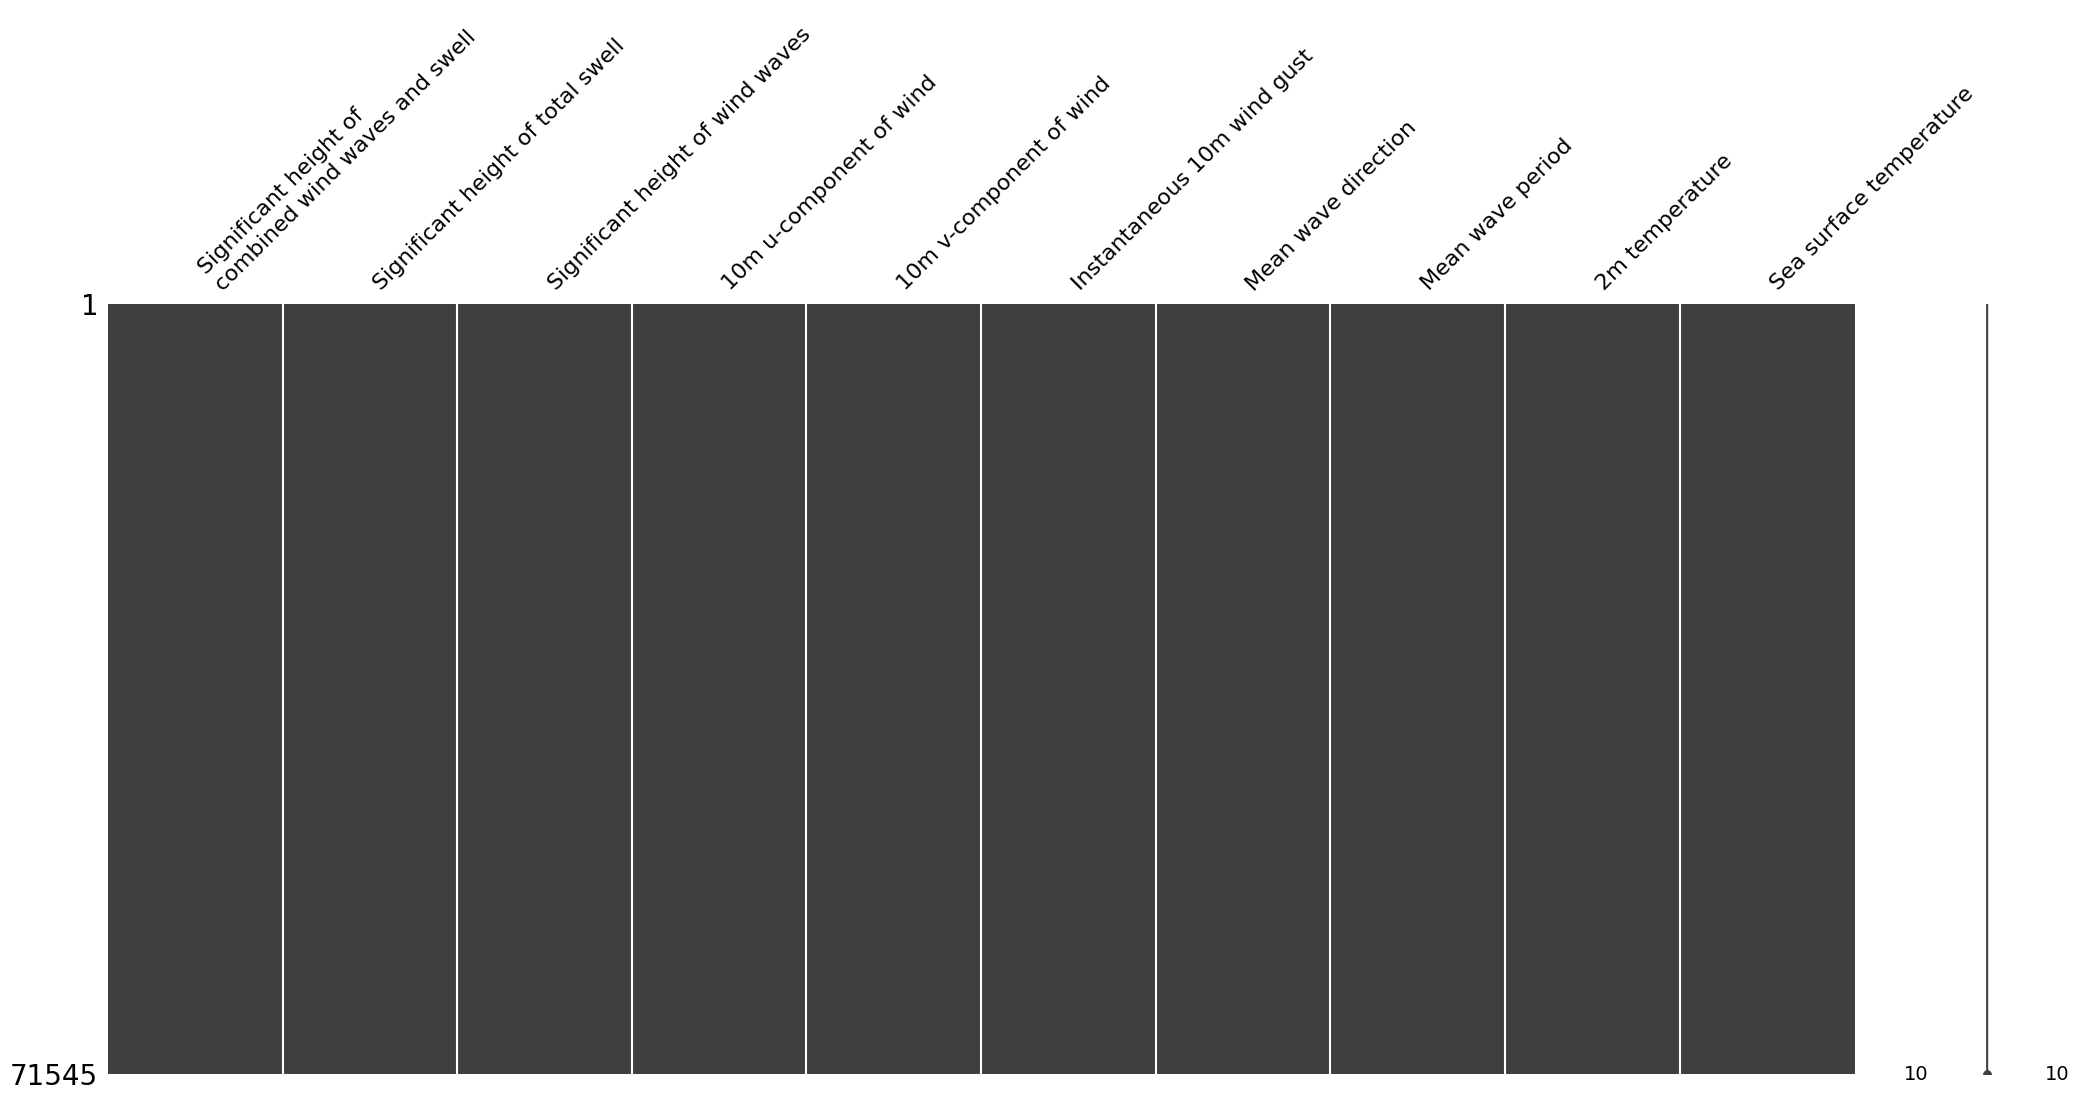

In [17]:
import missingno as msno
msno.matrix(HuasaiNakhonThammarat)

คอลัมน์ทั้ง 10 คอลัมน์ ไม่มีค่าที่หายไป

In [10]:
# กำหนดให้คอลัมน์ 'Time' เป็น Index ของ DataFrame และแปลงเป็น DatetimeIndex
# สร้าง DataFrame ใหม่เพื่อหลีกเลี่ยง SettingWithCopyWarning หรือทำงานกับ DataFrame ที่ถูกดึงมา
HuasaiNakhonThammarat_processed = HuasaiNakhonThammarat.copy()

# ตรวจสอบรูปแบบเวลาและแทนที่ '.00' ด้วย ':00' หากมี เพื่อให้เป็นรูปแบบมาตรฐาน (H:MM)
HuasaiNakhonThammarat_processed['Time'] = HuasaiNakhonThammarat_processed['Time'].str.replace('.00', ':00', regex=False)

# ตั้งค่าคอลัมน์ 'Time' เป็น Index
HuasaiNakhonThammarat_processed = HuasaiNakhonThammarat_processed.set_index('Time')

# ใช้ format='mixed' และ dayfirst=True เพื่อให้ pandas พยายามเดารูปแบบที่หลากหลาย
HuasaiNakhonThammarat_processed.index = pd.to_datetime(HuasaiNakhonThammarat_processed.index, format='mixed', dayfirst=True)

# อัปเดต DataFrame หลักด้วย DataFrame ที่ประมวลผลแล้ว
HuasaiNakhonThammarat = HuasaiNakhonThammarat_processed

# แสดงข้อความและ 5 แถวแรกของ DataFrame เพื่อให้เห็นว่าคอลัมน์ 'Time' ได้กลายเป็น Index
display("DataFrame with 'Time' as datetime index:")
display(HuasaiNakhonThammarat.head())

# แสดงชนิดข้อมูลของแต่ละคอลัมน์
display("Data types including index type:")
display(HuasaiNakhonThammarat.dtypes)

"DataFrame with 'Time' as datetime index:"

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
Time,,,,,,,,,,
2018-01-01 00:00:00,1.199359,1.163536,0.267764,-5.229365,-1.745424,10.239930,85.015228,6.285251,299.826065,300.587845
2018-01-01 01:00:00,1.202724,1.127065,0.404244,-6.057752,-2.017640,10.223330,85.037537,6.253075,299.346794,300.587845
2018-01-01 02:00:00,1.219304,1.102313,0.516395,-6.188400,-2.061301,10.456569,84.609726,6.132920,299.302010,300.587845
2018-01-01 03:00:00,1.232462,1.108556,0.535049,-5.875643,-2.021169,10.303367,84.249283,6.029561,299.322075,300.587845
2018-01-01 04:00:00,1.233244,1.123493,0.500552,-5.469970,-1.736256,9.888147,84.241928,5.985807,299.465080,300.587845


'Data types including index type:'

,0
Significant height of\ncombined wind waves and swell,float64
Significant height of total swell,float64
Significant height of wind waves,float64
10m u-component of wind,float64
10m v-component of wind,float64
Instantaneous 10m wind gust,float64
Mean wave direction,float64
Mean wave period,float64
2m temperature,float64
Sea surface temperature,float64


In [12]:
# ตรวจสอบ time difference ระหว่างแถวที่ติดกัน
time_diff = HuasaiNakhonThammarat.index.to_series().diff().dropna()

# สร้างเวกเตอร์ของ time difference
time_diff_vector = time_diff.values

# ตรวจสอบว่า time difference ทั้งหมดเท่ากับ 1 ชั่วโมงหรือไม่
# เนื่องจาก time_diff เป็น TimedeltaIndex, เราสามารถเปรียบเทียบกับ pd.Timedelta(hours=1)
is_one_hour = (time_diff == pd.Timedelta(hours=1))

# ตรวจสอบว่ามีค่าใดที่ไม่เท่ากับ 1 ชั่วโมงหรือไม่
if not is_one_hour.all():
    display("พบความแตกต่างของเวลาที่ไม่เท่ากับ 1 ชั่วโมง:")
    display(time_diff[~is_one_hour])
else:
    display("ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด")

    display("ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:")
display(time_diff.head())
display("...")
display(time_diff.tail())

'พบความแตกต่างของเวลาที่ไม่เท่ากับ 1 ชั่วโมง:'

,Time
Time,
2026-01-01,0 days


,Time
Time,
2018-01-01 01:00:00,0 days 01:00:00
2018-01-01 02:00:00,0 days 01:00:00
2018-01-01 03:00:00,0 days 01:00:00
2018-01-01 04:00:00,0 days 01:00:00
2018-01-01 05:00:00,0 days 01:00:00


'...'

,Time
Time,
2026-02-28 19:00:00,0 days 01:00:00
2026-02-28 20:00:00,0 days 01:00:00
2026-02-28 21:00:00,0 days 01:00:00
2026-02-28 22:00:00,0 days 01:00:00
2026-02-28 23:00:00,0 days 01:00:00


In [14]:
# Check for duplicate rows
duplicate_rows = HuasaiNakhonThammarat[HuasaiNakhonThammarat.duplicated()]

if duplicate_rows.empty:
    display("ไม่มีแถวที่ซ้ำกันในข้อมูล")
else:
    display("พบแถวที่ซ้ำกันในข้อมูล:")
    display(duplicate_rows)

'ไม่มีแถวที่ซ้ำกันในข้อมูล'

In [16]:
index_duplicates = HuasaiNakhonThammarat.index.duplicated()

if not index_duplicates.any():
    display("ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)")
    display("ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว")
else:
    display("พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Duplicate Timestamps)!")

    # แสดงให้เห็นว่าเวลาไหนที่ซ้ำ
    duplicate_times = HuasaiNakhonThammarat.index[index_duplicates].unique()
    display(f"พบเวลาที่ซ้ำซ้อนกัน {len(duplicate_times)} จุดเวลา:")
    display(duplicate_times)

    # แสดงแถวที่ซ้ำทั้งหมด (ทั้งแถวเก่าและแถวใหม่ที่ซ้ำกัน)
    display("แถวข้อมูลทั้งหมดที่มีเวลาซ้ำซ้อนกัน:")
    display(HuasaiNakhonThammarat[HuasaiNakhonThammarat.index.duplicated(keep=False)])

"พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Duplicate Timestamps)!"

'พบเวลาที่ซ้ำซ้อนกัน 1 จุดเวลา:'

DatetimeIndex(['2026-01-01'], dtype='datetime64[ns]', name='Time', freq=None)

'แถวข้อมูลทั้งหมดที่มีเวลาซ้ำซ้อนกัน:'

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m u-component of wind,10m v-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
Time,,,,,,,,,,
2026-01-01,0.438132,0.419790,0.096141,-3.400208,0.364832,4.917166,92.274704,4.419727,299.581947,301.35331
2026-01-01,0.413054,0.403687,0.055908,-2.958511,0.244507,4.450079,93.260925,4.378498,299.622589,301.36206
